# Post-result trading attribution

This explanatory analysis uses the 149 positions already recorded by the frozen evaluator at `59c02d73dc9134dcb157d4f2fbf06adf0d5db22c`, with results committed at `2b11b369e8bea4aa1c483829e330885b1acb40cc`. It neither selects new trades nor refits forecasts. Trading outcomes were known before this attribution was specified; it is not a new confirmation test.

The questions are the actual long/short balance and how the saved option/hedge P&L divides along a transparent repricing path. Only aggregate outputs are published; reconstructed contract inputs stay in gitignored processed data.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.trade_attribution import (
    COMPONENTS, direction_summary, load_saved_exit_marks, attribute_saved_trades,
)
from src.time_series import build_daily_time_series

AUDIT = ROOT / "data/processed/trading_locked_2025"
manifest = json.loads((AUDIT / "trading_locked_2025_run.json").read_text())
assert manifest["status"] == "completed"
assert manifest["evaluator_commit"] == "59c02d73dc9134dcb157d4f2fbf06adf0d5db22c"
trades = pd.read_csv(AUDIT / "trading_locked_2025_trades.csv",
                     parse_dates=["origin_date", "entry_date", "actual_exit"])
legs = pd.read_csv(AUDIT / "trading_locked_2025_legs.csv",
                   parse_dates=["origin_date", "quote_date", "expiry_date"])
spx = pd.read_csv(ROOT / "data/raw/spx_security_prices.csv", parse_dates=["date"])

## Actual direction mix

Positive means long 30D downside RR / short 60D downside RR. Negative reverses all four wings. Count signals, reachable entries and evaluated trades separately. The intercept alone does not establish the empirical direction balance; the z-score distribution matters.

In [2]:
directions = direction_summary(trades)
display(directions)
fit = manifest["signal_fit"]
print(f"Algebraic zero crossing of the existing forecast: z = {-fit['intercept'] / fit['slope']:.4f}")
print("This is a description of the existing linear forecast, not an added trading threshold.")

,n,positive,negative,positive_fraction
sample,,,,
finite signals,162,97,65,0.598765
reachable entries,157,92,65,0.585987
evaluated trades,149,89,60,0.597315


Algebraic zero crossing of the existing forecast: z = 0.3789
This is a description of the existing linear forecast, not an added trading threshold.


## Attribution definition

Use the original quantities and observed entry/exit quotes. Recover exit $F,D,\sigma$ with the existing parity and midpoint-IV functions for the same contracts; no SVI fit or contract reselection is involved.

Reprice the fixed basket in this stated order:

1. **Time/discount:** change $\tau,D$ to exit values, holding entry forward and IV fixed.
2. **Spot repricing:** scale entry forward by $S_1/S_0$, holding its entry forward/spot ratio fixed.
3. **Forward basis:** change that forward to the observed exit forward.
4. **IV level and held-wing shape:** move to the observed exit IVs.

For each tenor's original put/call pair, define $L=(\log\sigma_P+\log\sigma_C)/2$ and $A=(\log\sigma_P-\log\sigma_C)/2$. Thus $\sigma_P=e^{L+A}$ and $\sigma_C=e^{L-A}$. The level measures the geometric mean IV; shape measures the IV ratio. Log coordinates keep all counterfactual IVs positive. Average the level-first and shape-first paths to share their interaction equally.

Finally add the **saved daily hedge P&L** and **saved execution drag**. Report the endpoint-pricing residual and require reconciliation to the existing executable total.

This decomposition is exact as a sum, but its allocation is path-dependent. Time/discount is not a uniquely identified economic carry return, and held-wing shape is **not** constant-delta, constant-maturity RR25. Spot-vol interactions are allocated by the stated ordering; this does not identify causal skew alpha or eliminate gamma/vanna/volga exposure.

In [3]:
exit_path = ROOT / "data/processed/trading_attribution_exit_marks.csv"
if exit_path.exists():
    exit_marks = pd.read_csv(exit_path, parse_dates=["quote_date", "expiry_date"])
else:
    exit_marks = load_saved_exit_marks(
        ROOT / "data/raw/spx_option_prices_2025.csv", trades, legs
    )
    exit_marks.to_csv(exit_path, index=False)
attribution = attribute_saved_trades(trades, legs, exit_marks, spx)
assert len(attribution) == 149
attribution.to_csv(ROOT / "data/processed/trading_attribution.csv", index=False)
totals = attribution[list(COMPONENTS)].sum()
summary = pd.DataFrame({"total": totals, "mean_per_trade": attribution[list(COMPONENTS)].mean()})
display(summary)
display(pd.Series({
    "existing_executable_total": attribution.executable_total_pnl.sum(),
    "reconstructed_total": attribution.reconstructed_total.sum(),
    "maximum_absolute_trade_reconciliation_error": (
        attribution.reconstructed_total - attribution.executable_total_pnl
    ).abs().max(),
    "maximum_absolute_endpoint_pricing_residual": attribution.pricing_residual.abs().max(),
    "spot_repricing_plus_actual_hedge": totals.spot_repricing + totals.hedge_pnl,
}, name="reconciliation").to_frame())

,total,mean_per_trade
time_discount,4.373527e-03,2.935253e-05
spot_repricing,-3.173552e-01,-2.129901e-03
forward_basis,4.965836e-03,3.332776e-05
iv_level,9.145197e-04,6.137716e-06
held_wing_shape,-1.677145e-03,-1.125601e-05
hedge_pnl,2.792273e-01,1.874008e-03
execution_drag,-1.663953e-01,-1.116747e-03
pricing_residual,2.021910e-12,1.356986e-14


,reconciliation
existing_executable_total,-1.959465e-01
reconstructed_total,-1.959465e-01
maximum_absolute_trade_reconciliation_error,2.016616e-16
maximum_absolute_endpoint_pricing_residual,2.878461e-13
spot_repricing_plus_actual_hedge,-3.812798e-02


## Aggregate components

Pooled trade sums are overlapping and descriptive, in the existing unit-entry-gross-vega convention. The large spot repricing and hedge terms should be interpreted together. Each bar is an attribution component, not an independently traded strategy.

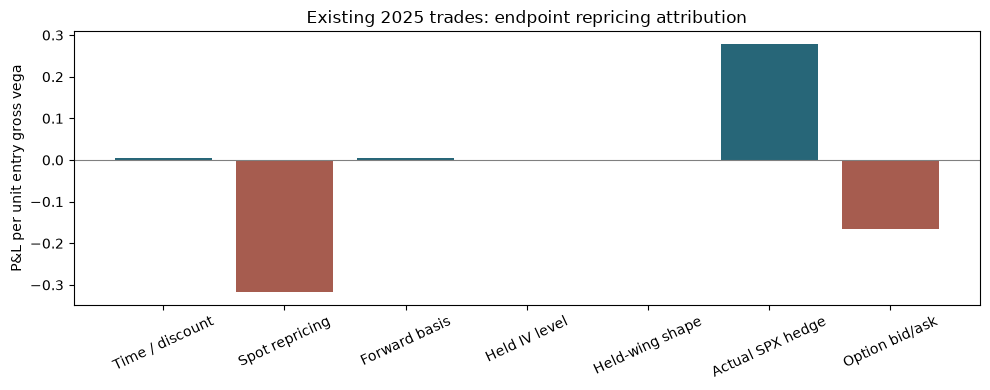

In [4]:
labels = {
    "time_discount": "Time / discount", "spot_repricing": "Spot repricing",
    "forward_basis": "Forward basis", "iv_level": "Held IV level",
    "held_wing_shape": "Held-wing shape", "hedge_pnl": "Actual SPX hedge",
    "execution_drag": "Option bid/ask",
}
values = totals[list(labels)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(list(labels.values()), values, color=["#276678" if value >= 0 else "#a65c4f" for value in values])
ax.axhline(0, color="grey", linewidth=.8)
ax.set(title="Existing 2025 trades: endpoint repricing attribution",
       ylabel="P&L per unit entry gross vega")
ax.tick_params(axis="x", labelrotation=25)
fig.tight_layout()
plt.show()

## Forecasting coverage versus trading coverage

Forecast scoring needs a QC-approved RR25 state at both endpoints. A previously entered trade still has realised option P&L if the later surface metric fails QC. Count that difference without excluding positions or changing the frozen result.

In [5]:
metrics = pd.read_csv(ROOT / "data/processed/spx_skew_metrics_2023_2025.csv",
                      parse_dates=["quote_date"])
daily = build_daily_time_series(metrics, spx).set_index("quote_date")
evaluated = trades.loc[trades.status.eq("evaluated")].copy()
evaluated["forecast_endpoint_available"] = (
    evaluated.origin_date.map(daily.rr25_30_60).notna()
    & evaluated.actual_exit.map(daily.rr25_30_60).notna()
)
display(evaluated.groupby("forecast_endpoint_available").agg(
    trades=("origin_date", "size"), midpoint_total=("midpoint_total_pnl", "sum"),
    executable_total=("executable_total_pnl", "sum"),
))
print("No trade is removed retrospectively because its future surface metric is unavailable.")

,trades,midpoint_total,executable_total
forecast_endpoint_available,,,
False,2,-0.013680,-0.023432
True,147,-0.015871,-0.172515


No trade is removed retrospectively because its future surface metric is unavailable.


## Interpretation boundary

The saved strategy took 89 positive and 60 negative directions (59.73% positive), so the direction table replaces the conjecture that it was effectively constant long. Under the declared attribution, time/discount contributes +0.004374, forward basis +0.004966, held IV level +0.000915 and held-wing shape -0.001677. Spot repricing plus the saved hedge contributes -0.038128, before execution drag of -0.166395. Their sum reconciles to the original -0.195946 executable total.

This locates the large arithmetic contributions without labelling the spot/hedge residual a coding error or uniquely identifying it as gamma loss. The allocation depends on the stated repricing order and counterfactual IV coordinates. It cannot establish a uniquely measured return to the forecasted constant-tenor surface skew. Forecasting and trading remain separate empirical findings.

The original 149-trade totals, two diagnostic controls and five offsets remain the locked result. No threshold, magnitude sizing, alternative holding period or new P&L experiment is introduced. Any future trading design would require a separately frozen test on outcomes not examined during this research.